In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.analysis.calculate_metastability_optimize_K import (find_optimal_K,
                                                             plot_K_optimization,
                                                             plot_arr_K_optimization
)

%load_ext autoreload
%autoreload 2 

# Create a new type of weighted connectome (distance matrix)

In [4]:
# Newly constructed connectivity matrix from distance matrix 
# name_data = "distance_matrix_50"
# name_data = "00_connectomes_orig" # 
name_data = "01_consensus_bin_density_10_percent_50"


################################### EITHER: ###################################

if name_data.startswith("distance_matrix"):
    # Load distance matrices and convert to connectomes
    distance_matrix_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/02_distance_matrices/{name_data}.npy"
    distance_matrices = np.load(distance_matrix_path)

    connectomes = []
    for d in distance_matrices:
        A = np.exp(-d / d.max())
        np.fill_diagonal(A, 0)  # No self-connections
        A = (A + A.T) / 2  # Make symmetric
        A = (A - A.min()) / (A.max() - A.min())
        np.fill_diagonal(A, 0)  # No self-connections
        connectomes.append(A)

    connectomes = np.array(connectomes)
    name_data = name_data + "_not_thresholded"


################################### OR: ###################################


if name_data.startswith("01_consensus") or name_data.startswith("00_connectomes"):
    # Load preprocessed connectomes
    data_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/{name_data}.npy"
    connectomes = np.load(data_path)


In [5]:
# wei: 
# # data_path = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/00_connectomes_orig.npy"

# dataset_type_name = "01_consensus_bin_density_10_percent_50"

# # bin and thres and sampled to 100 nodes total: 
# data_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/{dataset_type_name}.npy"
# connectomes = np.load(data_path)

# A = connectomes[0]

# Calculating optimal Ks

In [6]:
save_path = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/metastability_optimize_K/{name_data}_finer_window")
save_path.mkdir(parents=True, exist_ok=True)


ids_to_evaluate = [0, 103, 169, 188, 206]
K_range = np.logspace(2, 4, 41) # -4, 3, 41)
optimal_metric = 'global'

In [7]:
from src.analysis.dynamic_measures import spectral_radius

Optimizing K: 100%|██████████| 41/41 [01:53<00:00,  2.78s/it]



Optimization Results:
Metric optimized: global
Optimal K: 975.0000
Value at optimal K: 0.1072
K range tested: [0.0000, 3000.0000]
Number of K values: 41



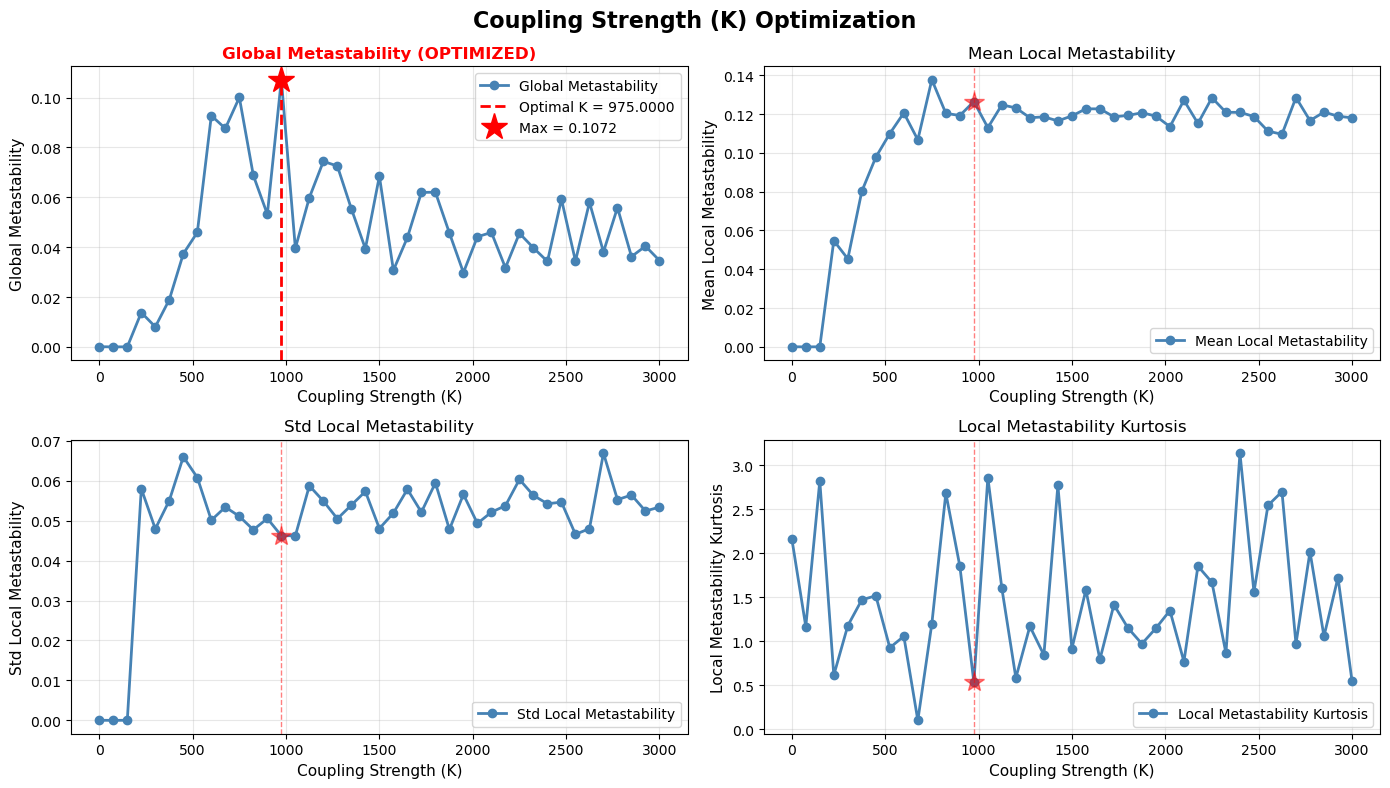

Optimizing K: 100%|██████████| 41/41 [02:27<00:00,  3.60s/it]



Optimization Results:
Metric optimized: global
Optimal K: 525.0000
Value at optimal K: 0.0926
K range tested: [0.0000, 3000.0000]
Number of K values: 41



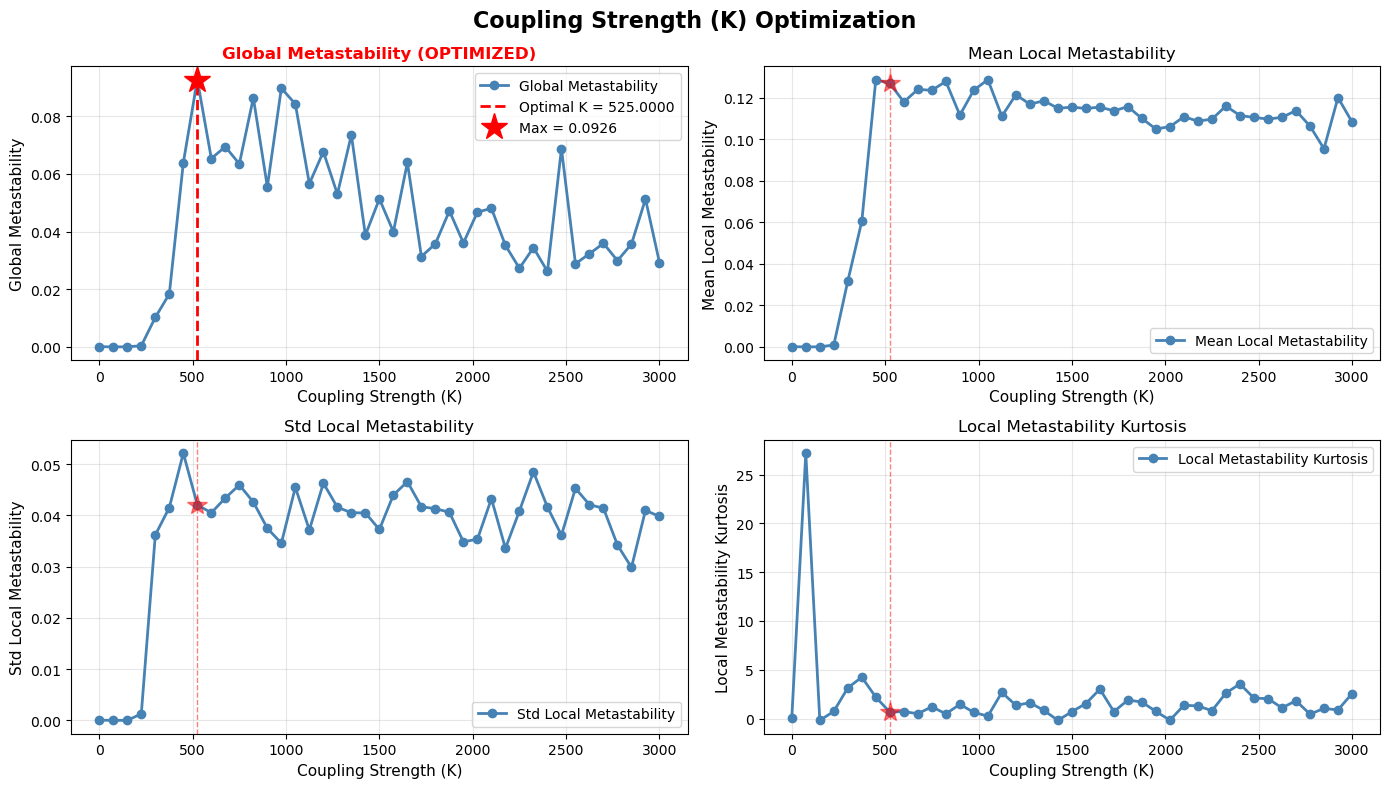

Optimizing K: 100%|██████████| 41/41 [02:50<00:00,  4.17s/it]



Optimization Results:
Metric optimized: global
Optimal K: 825.0000
Value at optimal K: 0.1277
K range tested: [0.0000, 3000.0000]
Number of K values: 41



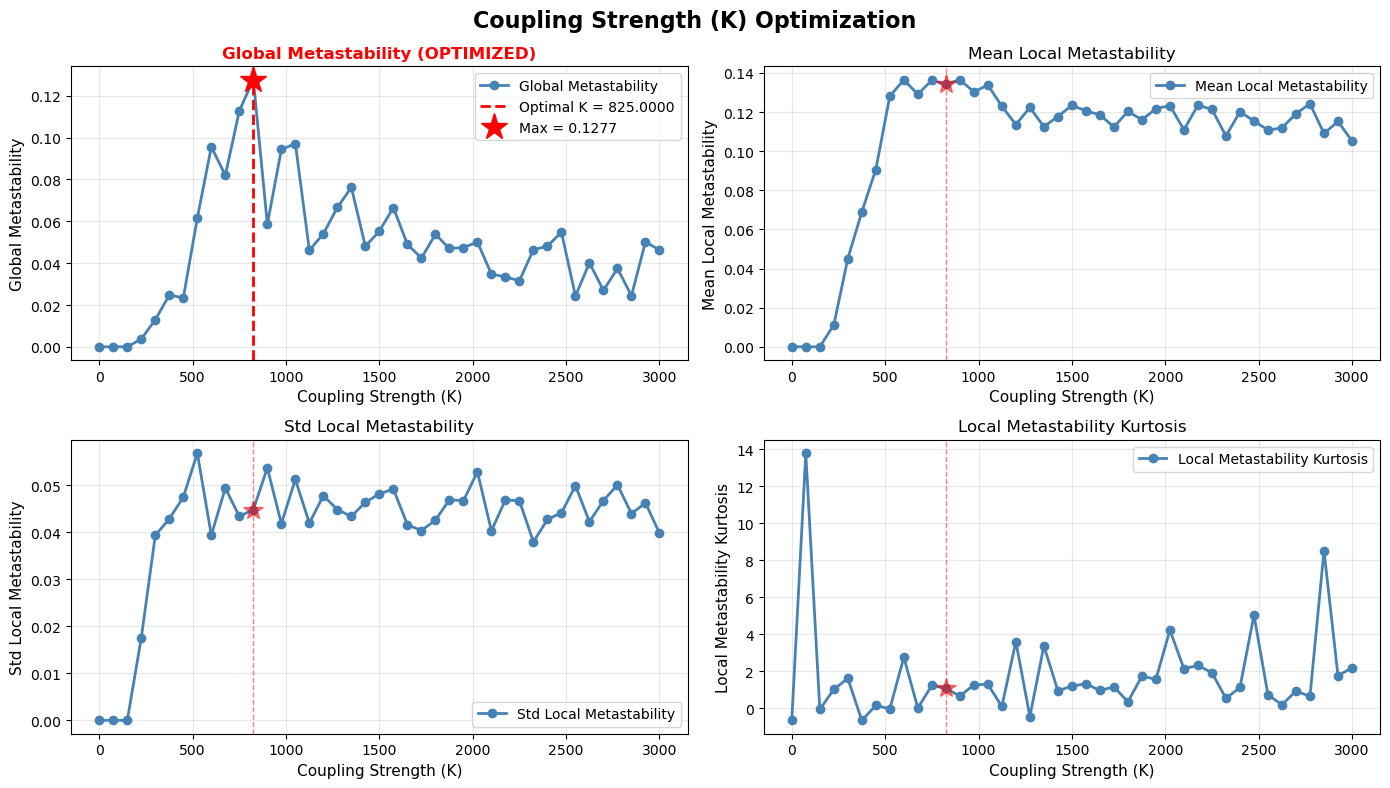

Optimizing K: 100%|██████████| 41/41 [02:28<00:00,  3.61s/it]



Optimization Results:
Metric optimized: global
Optimal K: 900.0000
Value at optimal K: 0.1013
K range tested: [0.0000, 3000.0000]
Number of K values: 41



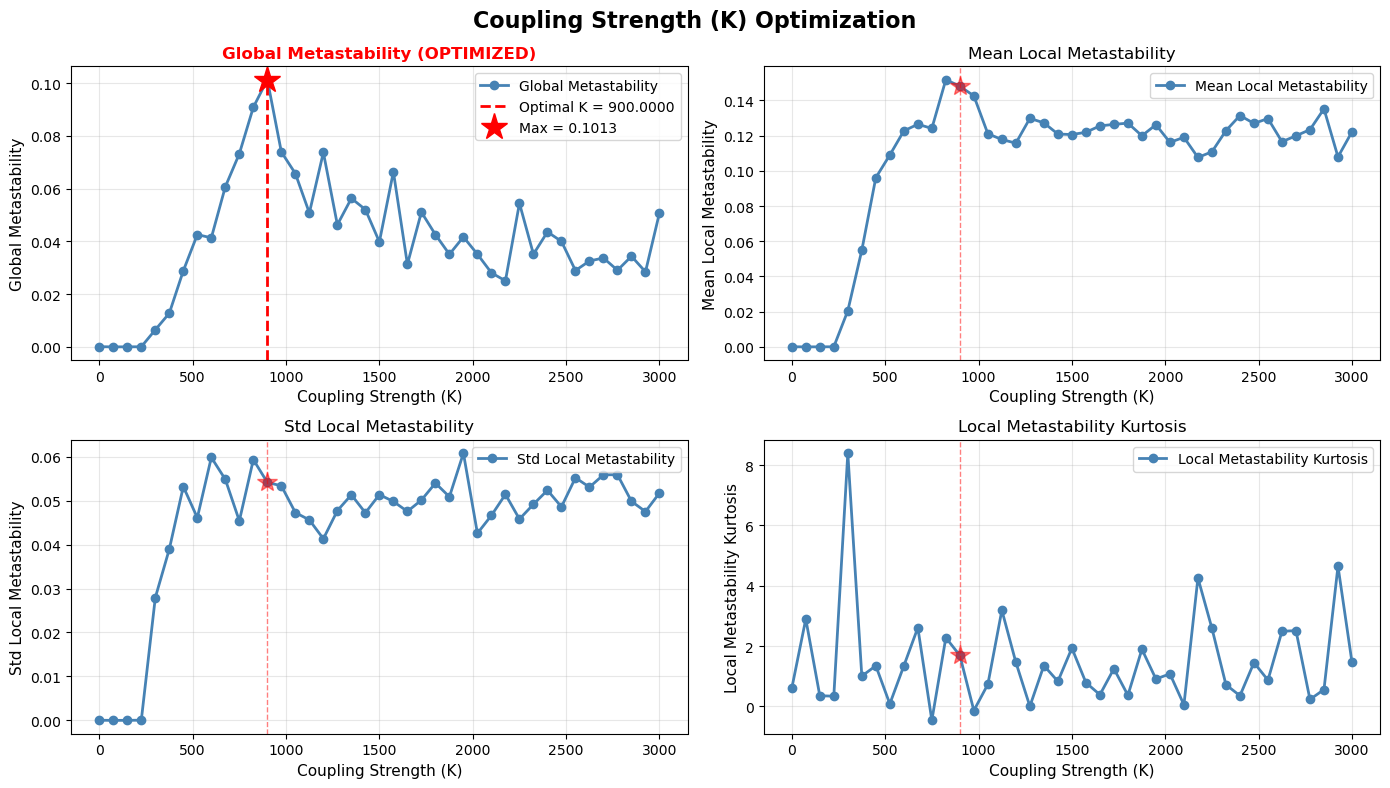

Optimizing K: 100%|██████████| 41/41 [01:51<00:00,  2.73s/it]


Optimization Results:
Metric optimized: global
Optimal K: 600.0000
Value at optimal K: 0.1226
K range tested: [0.0000, 3000.0000]
Number of K values: 41



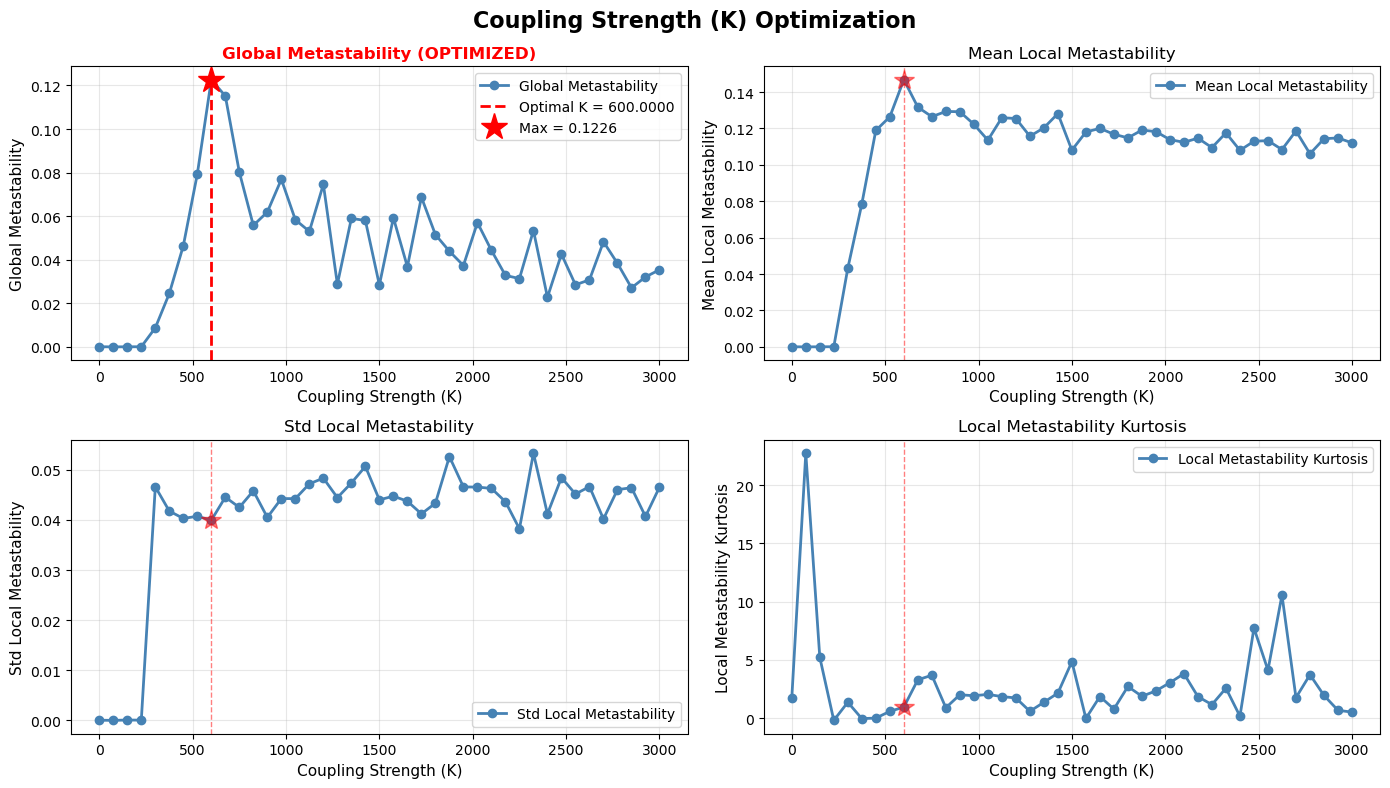

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/metastability_optimize_K/01_consensus_bin_density_10_percent_50_finer_window


In [8]:
# bin and thres and sampled to 100 nodes total: 

ids_to_evaluate = [0, 103, 169, 188, 206]
K_range = np.linspace(0, 3000, 41) # np.logspace(-4, 3, 41)
optimal_metric = 'global'


# First get optimal K for each animal, if this is already saved, load it
if (save_path / "K_optimal_arr.npy").exists():
    optimal_K_arr = np.load(save_path / "K_optimal_arr_partial.npy").tolist()
    results_arr = np.load(save_path / "results_arr_partial.npy", allow_pickle=True).tolist()
    start_idx_arr = np.load(save_path / "evaluated_ids_partial.npy").tolist()
else:
    start_idx = 0
    optimal_K_arr = [] 
    results_arr = [] 
    start_idx_arr = []

ids_to_evaluate = set(ids_to_evaluate) - set(start_idx_arr)
ids_to_evaluate = list(ids_to_evaluate)


for animal_id in ids_to_evaluate: 
    A = connectomes[animal_id]

    # A = (A + A.T) / 2  # Make symmetric
    # np.fill_diagonal(A, 0)  # No self-connections
    # A = A / A.sum(axis=1, keepdims=True)  # Normalize
    
    A = A / spectral_radius(A)  # Normalize by spectral radius

    # Find optimal K
    optimal_K, results = find_optimal_K(
        A, 
        K_range=K_range,
        metric=optimal_metric, 
        sim_time=500,  # Shorter for example
        verbose=True
    )

    # Plot results
    plot_K_optimization(results)
    plt.show()
    
    results = {"optimal_K": optimal_K, 
                "results": results}

    results_arr.append(results)
    optimal_K_arr.append(optimal_K)
    start_idx_arr.append(animal_id)

    # save intermediate results
    np.save(save_path / f"results_arr_partial_animal_id_{animal_id}.npy", results_arr)
    np.save(save_path / f"K_optimal_arr_partial_animal_id_{animal_id}.npy", optimal_K_arr)
    np.save(save_path / f"evaluated_ids_partial_animal_id_{animal_id}.npy", start_idx_arr)

    # break # 2:17  -> 1:03

print(save_path)
# total: 54 min for 5 animals (when 200 total nodes)

In [9]:
for id in ids_to_evaluate: 
    results_arr = np.load(save_path / f"results_arr_partial_animal_id_{id}.npy", allow_pickle=True)
    start_idx_arr = np.load(save_path / f"evaluated_ids_partial_animal_id_{id}.npy", allow_pickle=True)

In [10]:
for res in results_arr: 
    print(res["results"].keys()) # ["optimal_K"])
    print(res.keys())

dict_keys(['K_values', 'global', 'local_mean', 'local_std', 'local_kurtosis', 'DFA', 'optimal_K', 'optimal_metric', 'optimal_value'])
dict_keys(['optimal_K', 'results'])
dict_keys(['K_values', 'global', 'local_mean', 'local_std', 'local_kurtosis', 'DFA', 'optimal_K', 'optimal_metric', 'optimal_value'])
dict_keys(['optimal_K', 'results'])
dict_keys(['K_values', 'global', 'local_mean', 'local_std', 'local_kurtosis', 'DFA', 'optimal_K', 'optimal_metric', 'optimal_value'])
dict_keys(['optimal_K', 'results'])
dict_keys(['K_values', 'global', 'local_mean', 'local_std', 'local_kurtosis', 'DFA', 'optimal_K', 'optimal_metric', 'optimal_value'])
dict_keys(['optimal_K', 'results'])
dict_keys(['K_values', 'global', 'local_mean', 'local_std', 'local_kurtosis', 'DFA', 'optimal_K', 'optimal_metric', 'optimal_value'])
dict_keys(['optimal_K', 'results'])


Figure saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/metastability_optimize_K/01_consensus_bin_density_10_percent_50_finer_window/K_optimization_plots_01_consensus_bin_density_10_percent_50.pdf


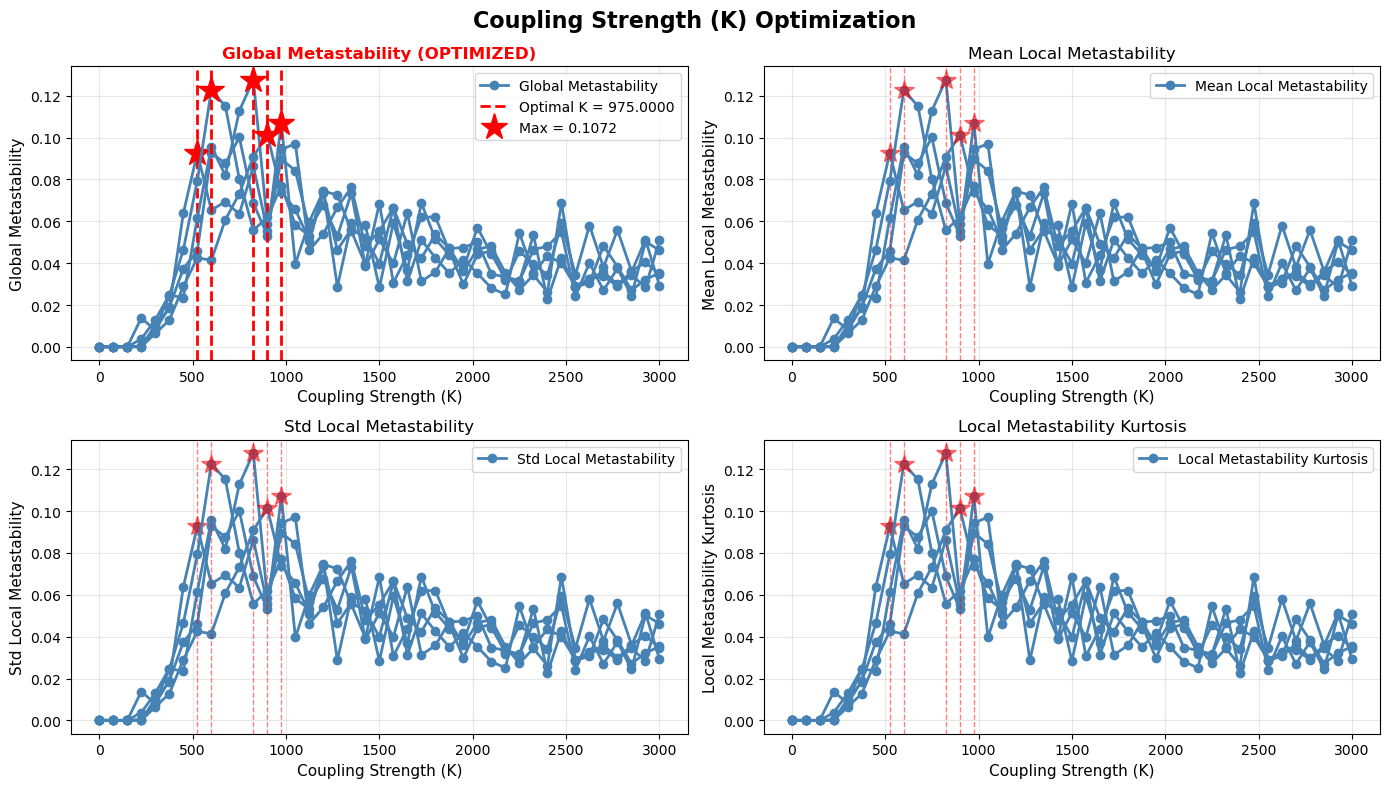

In [11]:
# plot_K_optimization(results)

plot_arr_K_optimization( # attention: Only seems to plot the global metric?? 
    results_arr,
    start_idx_arr,
    optimal_metric, 
    save_path=save_path / f"K_optimization_plots_{name_data}.pdf")

Optimizing K: 100%|██████████| 41/41 [01:53<00:00,  2.76s/it]


Optimization Results:
Metric optimized: global
Optimal K: 450.0000
Value at optimal K: 0.1223
K range tested: [0.0000, 3000.0000]
Number of K values: 41



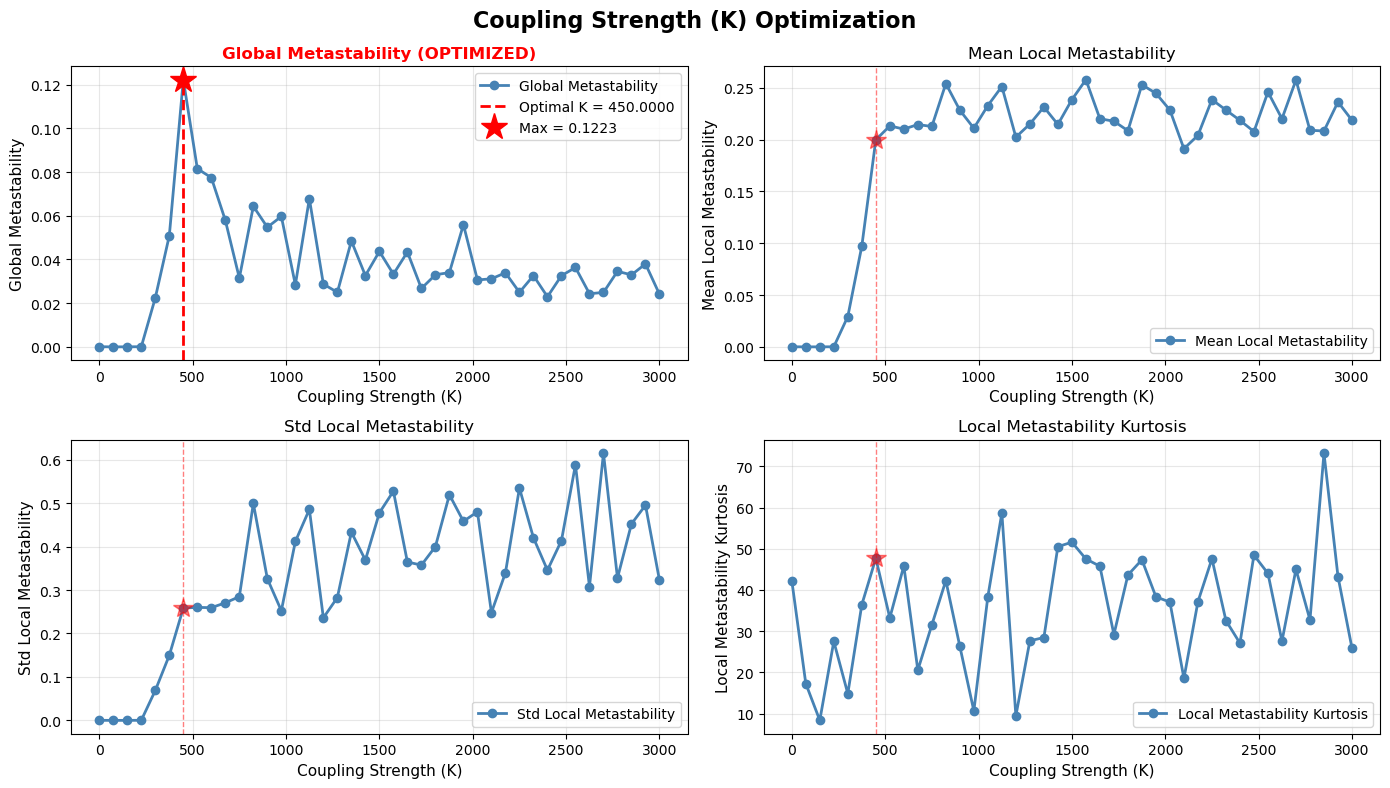

Optimizing K: 100%|██████████| 41/41 [01:51<00:00,  2.73s/it]


Optimization Results:
Metric optimized: global
Optimal K: 525.0000
Value at optimal K: 0.1390
K range tested: [0.0000, 3000.0000]
Number of K values: 41



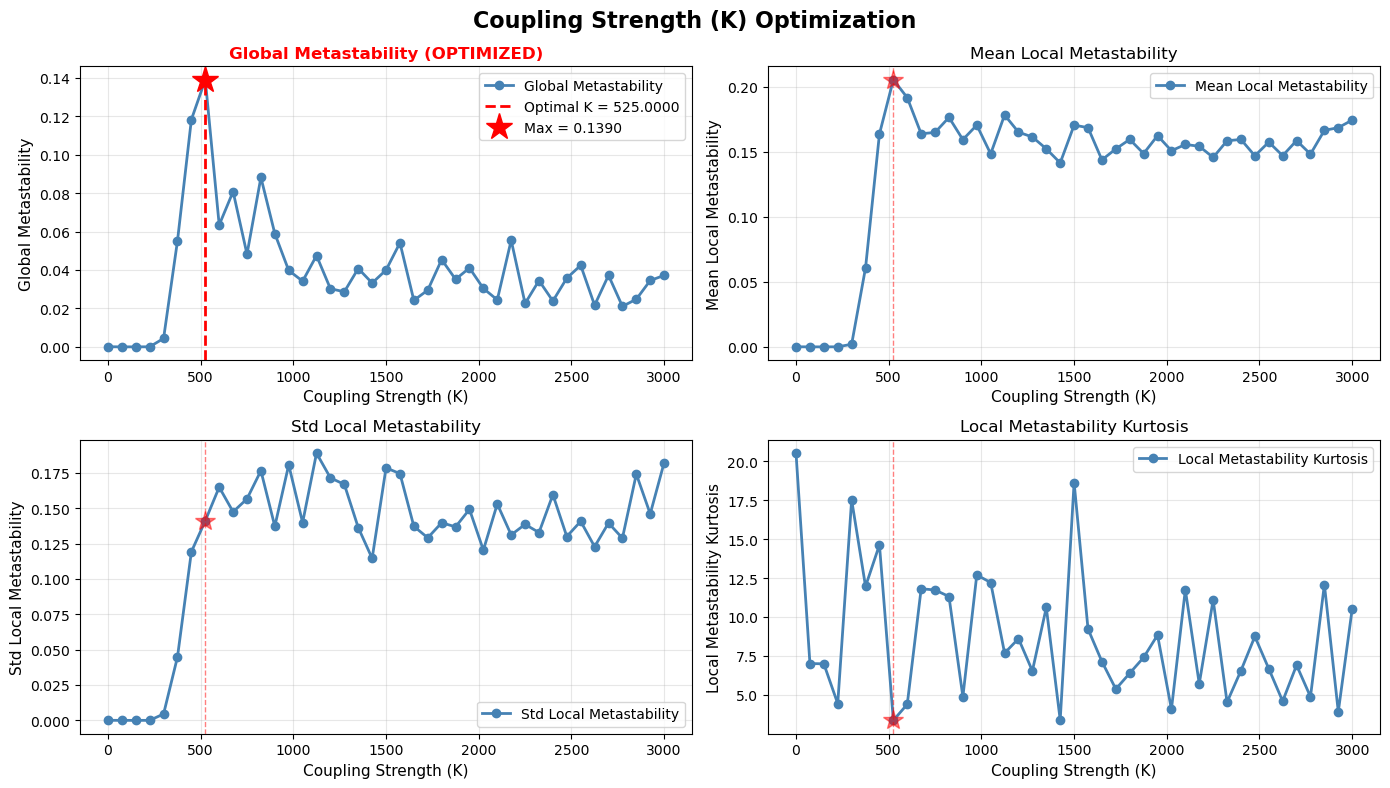

Optimizing K: 100%|██████████| 41/41 [01:52<00:00,  2.74s/it]


Optimization Results:
Metric optimized: global
Optimal K: 450.0000
Value at optimal K: 0.1044
K range tested: [0.0000, 3000.0000]
Number of K values: 41



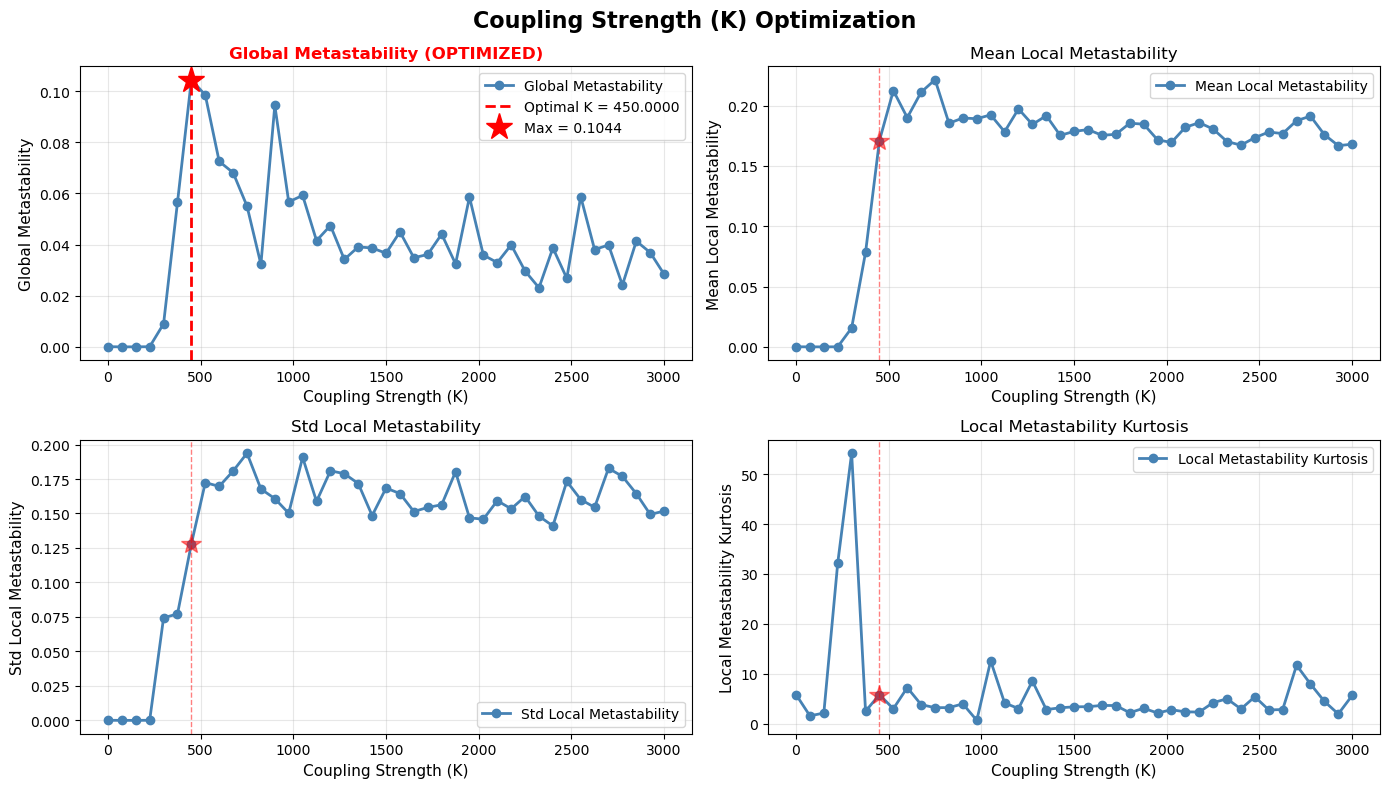

Optimizing K: 100%|██████████| 41/41 [01:53<00:00,  2.76s/it]


Optimization Results:
Metric optimized: global
Optimal K: 450.0000
Value at optimal K: 0.1130
K range tested: [0.0000, 3000.0000]
Number of K values: 41



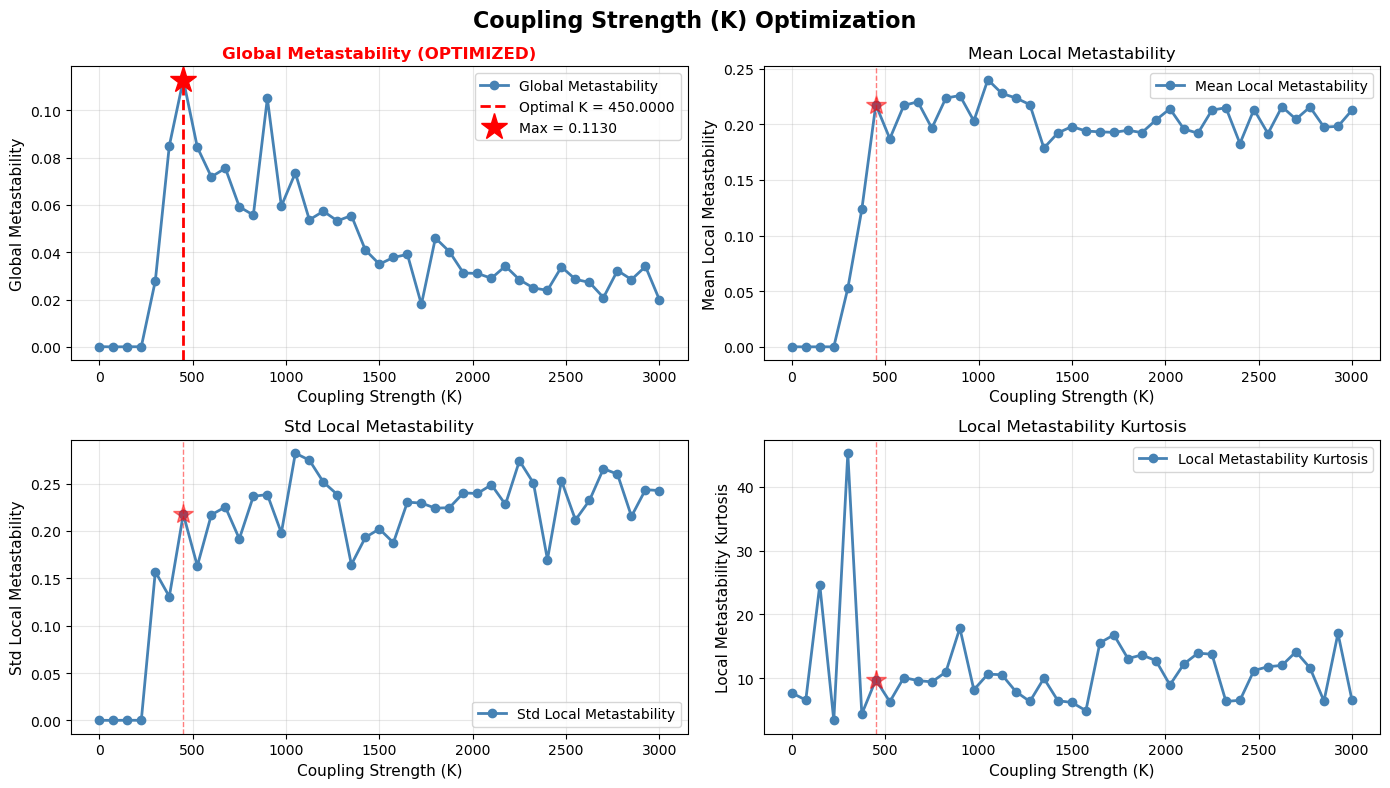

Optimizing K: 100%|██████████| 41/41 [01:52<00:00,  2.75s/it]


Optimization Results:
Metric optimized: global
Optimal K: 525.0000
Value at optimal K: 0.0992
K range tested: [0.0000, 3000.0000]
Number of K values: 41



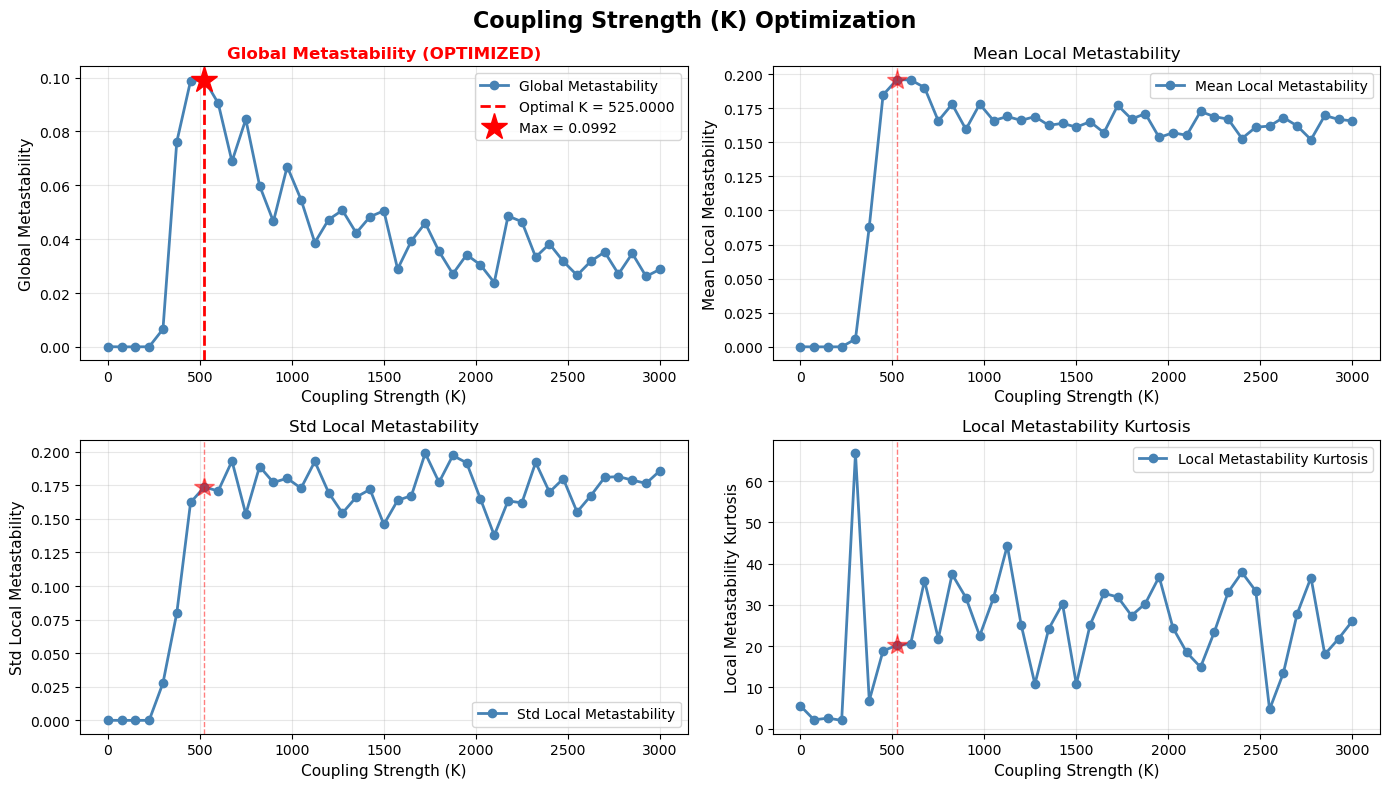

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/metastability_optimize_K/01_consensus_bin_density_10_percent_50_finer_window


In [12]:
# bin and thres and sampled to 100 nodes total: 

ids_to_evaluate = [0, 103, 169, 188, 206]
K_range = np.linspace(0, 3000, 41) # np.logspace(-4, 3, 41)
optimal_metric = 'global'


# First get optimal K for each animal, if this is already saved, load it
if (save_path / "K_optimal_arr.npy").exists():
    optimal_K_arr = np.load(save_path / "K_optimal_arr_partial.npy").tolist()
    results_arr = np.load(save_path / "results_arr_partial.npy", allow_pickle=True).tolist()
    start_idx_arr = np.load(save_path / "evaluated_ids_partial.npy").tolist()
else:
    start_idx = 0
    optimal_K_arr = [] 
    results_arr = [] 
    start_idx_arr = []

ids_to_evaluate = set(ids_to_evaluate) - set(start_idx_arr)
ids_to_evaluate = list(ids_to_evaluate)


for animal_id in ids_to_evaluate: 
    A = connectomes[animal_id]

    A = (A + A.T) / 2  # Make symmetric
    np.fill_diagonal(A, 0)  # No self-connections
    A = A / A.sum(axis=1, keepdims=True)  # Normalize

    # Find optimal K
    optimal_K, results = find_optimal_K(
        A, 
        K_range=K_range,
        metric=optimal_metric, 
        sim_time=500,  # Shorter for example
        verbose=True
    )

    # Plot results
    plot_K_optimization(results)
    plt.show()
    
    results = {"optimal_K": optimal_K, 
                "results": results}

    results_arr.append(results)
    optimal_K_arr.append(optimal_K)
    start_idx_arr.append(animal_id)

    # save intermediate results
    np.save(save_path / f"results_arr_partial_animal_id_{animal_id}.npy", results_arr)
    np.save(save_path / f"K_optimal_arr_partial_animal_id_{animal_id}.npy", optimal_K_arr)
    np.save(save_path / f"evaluated_ids_partial_animal_id_{animal_id}.npy", start_idx_arr)

    # break # 2:17  -> 1:03

print(save_path)
# total: 54 min for 5 animals (when 200 total nodes)

In [26]:
# optimal_K_arr = [] 
# results_arr = [] # Create a random connectivity matrix

# K_vec = np.logspace(-4, 3, 41)
# meta_stabilities = np.zeros(len(K_vec)) # ,212))
# # subset_W = connectomes[::10]
# # subset_W = A
# # meta_global_vec = np.zeros((len(K_vec)))

# # for i, K in enumerate(K_vec):
# #         meta_stabilities[i], _, _ = evaluate_network(W = W, K = K, sim_time = 500)
        
# # Find optimal K
# optimal_K, results = find_optimal_K(
#     A, 
#     K_range=np.logspace(-4, 3, 41), # np.linspace(0.0001, 0.1, 50),
#     metric='global',
#     sim_time=200,  # Shorter for example
#     verbose=True
# )

# # Plot results
# plot_K_optimization(results)

In [13]:
optimal_K

np.float64(525.0)

In [14]:
results

{'optimal_K': np.float64(525.0),
 'results': {'K_values': array([   0.,   75.,  150.,  225.,  300.,  375.,  450.,  525.,  600.,
          675.,  750.,  825.,  900.,  975., 1050., 1125., 1200., 1275.,
         1350., 1425., 1500., 1575., 1650., 1725., 1800., 1875., 1950.,
         2025., 2100., 2175., 2250., 2325., 2400., 2475., 2550., 2625.,
         2700., 2775., 2850., 2925., 3000.]),
  'global': array([7.17494450e-05, 2.20309698e-14, 1.07962113e-05, 3.91877325e-05,
         6.59581611e-03, 7.61283565e-02, 9.88092653e-02, 9.92277974e-02,
         9.04914323e-02, 6.88767020e-02, 8.45156128e-02, 5.98825026e-02,
         4.65633805e-02, 6.69765339e-02, 5.47226448e-02, 3.87132241e-02,
         4.72787811e-02, 5.07395795e-02, 4.22989991e-02, 4.83350203e-02,
         5.05262030e-02, 2.89032845e-02, 3.93912831e-02, 4.59830210e-02,
         3.54582060e-02, 2.70834192e-02, 3.42231623e-02, 3.04409972e-02,
         2.38802081e-02, 4.86000141e-02, 4.64957443e-02, 3.33432055e-02,
         3.82382

# Generated connectomes

In [21]:
# from notebook_setup import setup
from vizman import viz
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd

from matplotlib import font_manager
for font in font_manager.findSystemFonts("figures/Atkinson_Typeface/"):
    font_manager.fontManager.addfont(font)

viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

# from kaysons_visual_config import * # Kayson's file. 

from src.visualization.find_and_plot_closest_connectome import find_closest_connectome, plot_connectome_blockwise, compare_orderings

# env = setup()

import numpy as np
from scipy.spatial.distance import squareform
from scipy.optimize import minimize
import networkx as nx
from netgraph import Graph
import matplotlib.pyplot as plt
from pypalettes import load_cmap

from pypalettes import load_cmap
cmap = load_cmap("Aurora")

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from netgraph import Graph
from networkx.algorithms import community



In [22]:
subject_id = 206
experiment_name = "76_90000_samples_animal_206" 
base_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset") / experiment_name

data_dir = base_path / "generated_networks"
save_dir = base_path / "generated_networks_visualizations"
save_dir.mkdir(parents=True, exist_ok=True)

margin_x = 0.5
margin_y = 0.05
interesting_eta_and_gamma_combinations = [
    [-8+margin_x, 1-margin_y],  
    [3-margin_x, 1-margin_y], 
    [-0.8, 0.18],
    [3-margin_x, -0.1+margin_y], 
    [-8+margin_x, -0.1+margin_y],
    [-5, 0.5],
]

# Choose clustering method: 'spectral', 'hierarchical', 'modularity', 'degree', or None
clustering_method = 'spectral'

# Store connectomes and parameters
connectomes = []
params = []

# for parameter_combination in interesting_eta_and_gamma_combinations:
#     target_eta = parameter_combination[0]
#     target_gamma = parameter_combination[1]
    
#     found_eta, found_gamma, connectome = find_closest_connectome(target_eta, target_gamma, data_dir)
    
#     connectomes.append(connectome)
#     params.append((found_eta, found_gamma))
    
#     parameter_combination.append(found_eta)
#     parameter_combination.append(found_gamma)


In [23]:
from src.visualization.find_and_plot_closest_connectome import find_closest_connectome

In [24]:
connectomes_arr = []
eta_arr = []
gamma_arr = []


for i, parameter_combination in enumerate(interesting_eta_and_gamma_combinations):
    target_eta = parameter_combination[0]
    target_gamma = parameter_combination[1]
    
    found_eta, found_gamma, connectome = find_closest_connectome(target_eta, target_gamma, data_dir, number_connectomes=5)

    connectomes_arr.append(connectome)
    eta_arr.append(found_eta)
    gamma_arr.append(found_gamma)

connectomes_arr = np.concatenate(connectomes_arr)
print(connectomes_arr.shape)

Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/generated_networks
Found 5 closest file(s)
Target (η, γ): (-7.5, 0.95)
  1. net_eta-7.484950065612793_gamma0.948494970798492_ruleMatchingIndex_id000.npy - (η, γ): (-7.485, 0.948)
  2. net_eta-7.484950065612793_gamma0.952173888683319_ruleMatchingIndex_id000.npy - (η, γ): (-7.485, 0.952)
  3. net_eta-7.484950065612793_gamma0.944816052913665_ruleMatchingIndex_id000.npy - (η, γ): (-7.485, 0.945)
  4. net_eta-7.484950065612793_gamma0.95585286617279_ruleMatchingIndex_id000.npy - (η, γ): (-7.485, 0.956)
  5. net_eta-7.484950065612793_gamma0.941137135028839_ruleMatchingIndex_id000.npy - (η, γ): (-7.485, 0.941)
Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/generated_networks
Found 5 closest file(s)
Target (η, γ): (2.5, 0.95)
  1. net_eta2.484949827194214_gamma0.948494970798492

Optimizing K: 100%|██████████| 41/41 [01:50<00:00,  2.70s/it]


Optimization Results:
Metric optimized: global
Optimal K: 750.0000
Value at optimal K: 0.1066
K range tested: [0.0000, 3000.0000]
Number of K values: 41



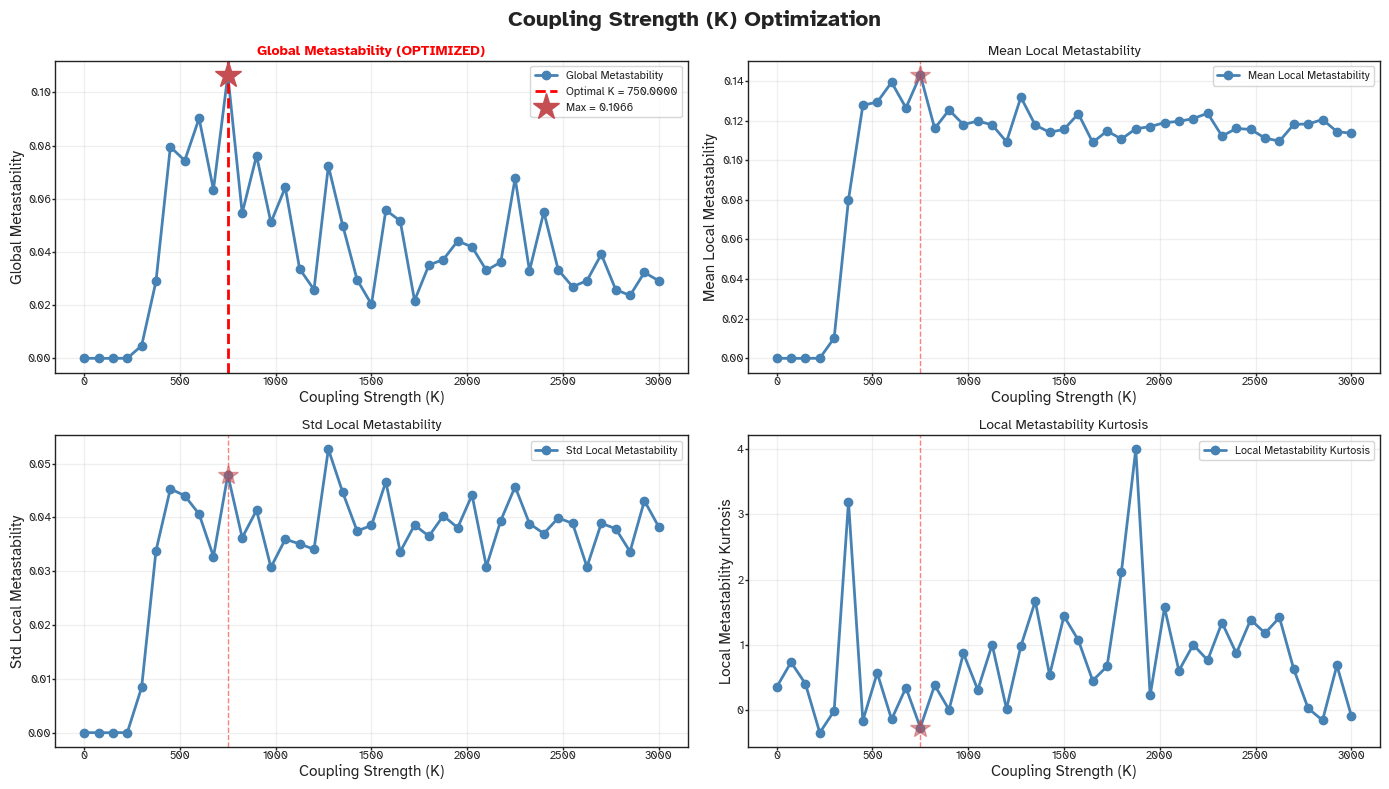

Optimizing K: 100%|██████████| 41/41 [01:52<00:00,  2.74s/it]


Optimization Results:
Metric optimized: global
Optimal K: 750.0000
Value at optimal K: 0.0933
K range tested: [0.0000, 3000.0000]
Number of K values: 41



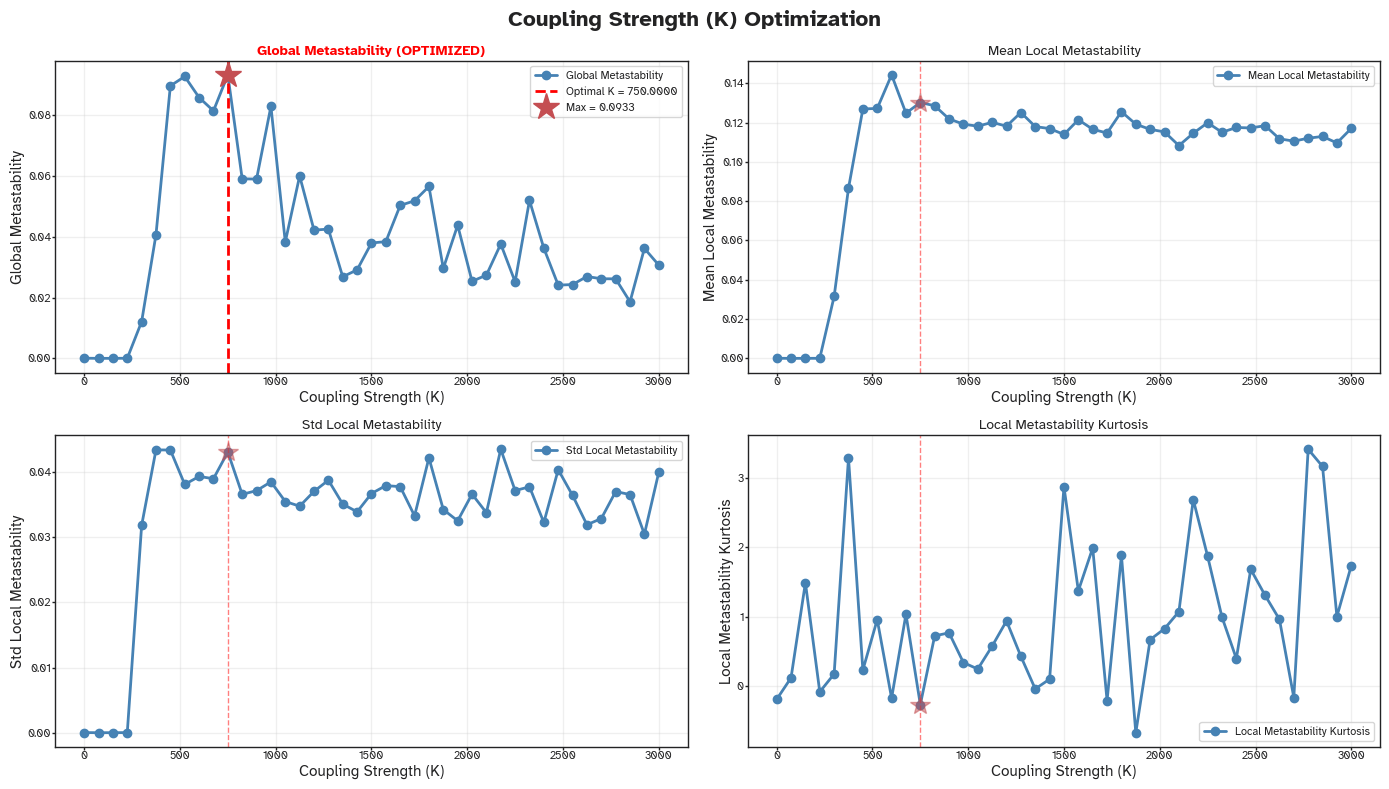

Optimizing K: 100%|██████████| 41/41 [01:53<00:00,  2.76s/it]


Optimization Results:
Metric optimized: global
Optimal K: 600.0000
Value at optimal K: 0.1171
K range tested: [0.0000, 3000.0000]
Number of K values: 41



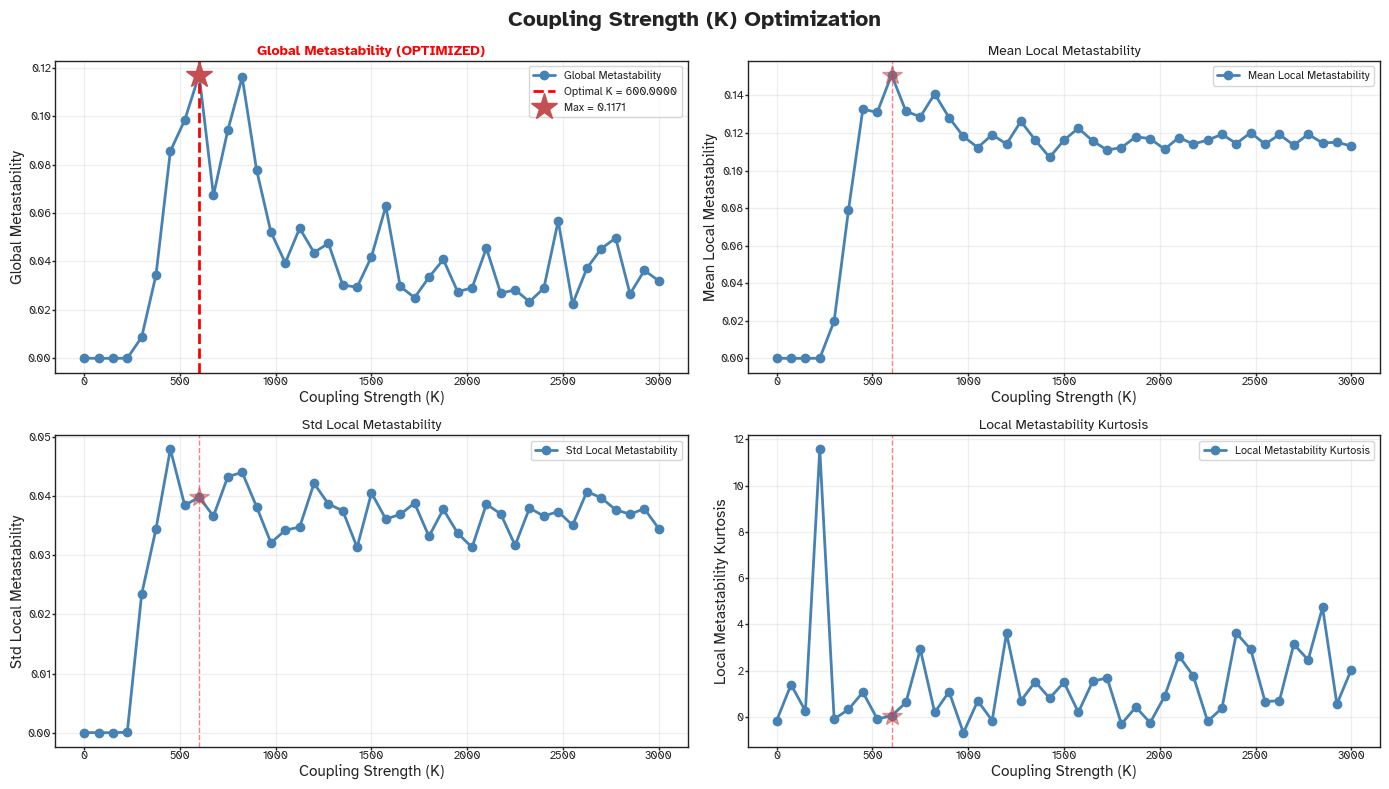

Optimizing K:  80%|████████  | 33/41 [01:29<00:22,  2.85s/it]

In [ ]:
save_path = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/metastability_optimize_K/generated_networks_30_{name_data}_finer_window")
save_path.mkdir(parents=True, exist_ok=True)


ids_to_evaluate = [0, 103, 169, 188, 206]
K_range = np.logspace(2, 4, 41) # -4, 3, 41)
optimal_metric = 'global'
from src.analysis.dynamic_measures import spectral_radius
# bin and thres and sampled to 100 nodes total: 

ids_to_evaluate = [0, 103, 169, 188, 206]
K_range = np.linspace(0, 3000, 41) # np.logspace(-4, 3, 41)
optimal_metric = 'global'

start_idx = 0
optimal_K_arr = [] 
results_arr = [] 
start_idx_arr = []

ids_to_evaluate = set(ids_to_evaluate) - set(start_idx_arr)
ids_to_evaluate = list(ids_to_evaluate)


for id in range(len(connectomes_arr)): # ids_to_evaluate: 
    A = connectomes_arr[id]

    # A = (A + A.T) / 2  # Make symmetric
    # np.fill_diagonal(A, 0)  # No self-connections
    # A = A / A.sum(axis=1, keepdims=True)  # Normalize
    
    A = A / spectral_radius(A)  # Normalize by spectral radius

    # Find optimal K
    optimal_K, results = find_optimal_K(
        A, 
        K_range=K_range,
        metric=optimal_metric, 
        sim_time=500,  # Shorter for example
        verbose=True
    )
    

    # Plot results
    plot_K_optimization(results)
    # plt.show()
    
    results = {"optimal_K": optimal_K, 
                "results": results}

    results_arr.append(results)
    optimal_K_arr.append(optimal_K)
    start_idx_arr.append(id)

    # save intermediate results
    np.save(save_path / f"results_arr_partial_animal_id_{id}.npy", results_arr)
    np.save(save_path / f"K_optimal_arr_partial_animal_id_{id}.npy", optimal_K_arr)
    np.save(save_path / f"evaluated_ids_partial_animal_id_{id}.npy", start_idx_arr)

    # break # 2:17  -> 1:03



In [ ]:


print(save_path)
# total: 54 min for 5 animals (when 200 total nodes)
for id in range(len(connectomes_arr)): # ids_to_evaluate:
    results_arr = np.load(save_path / f"results_arr_partial_animal_id_{id}.npy", allow_pickle=True)
    start_idx_arr = np.load(save_path / f"evaluated_ids_partial_animal_id_{id}.npy", allow_pickle=True)
for res in results_arr: 
    print(res["results"].keys()) # ["optimal_K"])
    print(res.keys())
# plot_K_optimization(results)

plot_arr_K_optimization( # attention: Only seems to plot the global metric?? 
    results_arr,
    start_idx_arr,
    optimal_metric, 
    save_path=save_path / f"K_optimization_plots_{name_data}.pdf")

In [ ]:
# optimal_Ks = []
# optimal_values = []
# labels = [] 

# for conn_arr, label in zip(np.array(connectomes_arr), ['A']*5 + ['B']*5 + ['C']*5 + ['D']*5 + ['E']*5 + ['F']*5): # list of stacks with each 5 connectomes
#     for conn in conn_arr: # stack of 5 connectomes
#         #  {"optimal_K": results["optimal_K"], 
#         #         "optimal_value": results["optimal_value"]}
        
#         optimal_K, optimal_value = calculate_metastability(conn, save_debug_path="/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/metastability_debug_for_notebook_results/")
#         optimal_Ks.append(optimal_K)
#         optimal_values.append(optimal_value)
#         labels.append(label)
